# Merged Human vs Non-Human - Rubble Robust

Bu notebook, `NIGENS + ESC-50 + TESS` uzerinden daha zorlayici boguk / enkaz benzeri kosullara dayanikli
bir model egitmek icin hazirlanmistir.

Ana farklar:
- daha agresif augment
- daha dusuk cutoff low-pass
- daha guclu noise ve reverb
- validation uzerinde threshold tuning
- quick test ve rubble test icin esik ayarli benchmark

## 1. Imports

In [1]:
import gc
import random
import warnings
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from scipy.signal import butter, fftconvolve, sosfiltfilt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, fbeta_score, precision_score, recall_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_SPLIT = True
except ImportError:
    StratifiedGroupKFold = None
    HAS_STRATIFIED_GROUP_SPLIT = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


## 2. Config

In [2]:
PROJECT_ROOT = Path(r"C:\projs\echo_swarm2")
NIGENS_ROOT = PROJECT_ROOT / "dataset" / "nigens" / "NIGENS" / "NIGENS"
ESC50_ROOT = PROJECT_ROOT / "dataset" / "esc-50" / "ESC-50-master"
ESC50_AUDIO_DIR = ESC50_ROOT / "audio"
ESC50_META_PATH = ESC50_ROOT / "meta" / "esc50.csv"
TESS_ROOT = PROJECT_ROOT / "dataset" / "tess" / "doi-10.5683-sp2-e8h2mf"

QUICK_TEST_ROOT = PROJECT_ROOT / "demo_samples" / "nigens_quick_test"
QUICK_TEST_MANIFEST = QUICK_TEST_ROOT / "manifest.csv"
RUBBLE_TEST_ROOT = PROJECT_ROOT / "demo_samples" / "nigens_rubble_test"
RUBBLE_TEST_MANIFEST = RUBBLE_TEST_ROOT / "manifest.csv"

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODEL_PATH = MODELS_DIR / "merged_human_nonhuman_rubble_best.pt"

NOTEBOOKS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
TEST_SIZE = 0.20
SAMPLE_RATE = 16_000
CLIP_SECONDS = 1.5
CLIP_SAMPLES = int(SAMPLE_RATE * CLIP_SECONDS)
BATCH_SIZE = 32
NUM_EPOCHS = 18
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 4
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
LOWPASS_PROB = 0.70
NOISE_PROB = 0.70
REVERB_PROB = 0.50
RANDOM_GAIN_PROB = 0.30
TESS_MAX_WORDS_PER_SPEAKER = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LABEL_TO_IDX = {"NON_HUMAN": 0, "HUMAN": 1}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"Device: {DEVICE}")
print(f"Model path: {MODEL_PATH}")


Device: cuda
Model path: C:\projs\echo_swarm2\models\merged_human_nonhuman_rubble_best.pt


## 3. Label Design

In [3]:
NIGENS_HUMAN_CLASSES = [
    "femaleScream",
    "maleScream",
    "femaleSpeech",
    "maleSpeech",
]

NIGENS_NON_HUMAN_CLASSES = [
    "alarm",
    "crash",
    "dog",
    "engine",
    "fire",
    "knock",
    "phone",
]

ESC50_HUMAN_CLASSES = [
    "breathing",
    "coughing",
    "laughing",
    "sneezing",
    "snoring",
]

ESC50_NON_HUMAN_CLASSES = [
    "airplane",
    "car_horn",
    "cat",
    "chainsaw",
    "church_bells",
    "clock_alarm",
    "cow",
    "crackling_fire",
    "crow",
    "dog",
    "door_wood_knock",
    "engine",
    "frog",
    "glass_breaking",
    "hand_saw",
    "helicopter",
    "hen",
    "pig",
    "rooster",
    "sheep",
    "siren",
    "train",
    "vacuum_cleaner",
    "washing_machine",
]

display(
    pd.DataFrame(
        [
            {"Kaynak": "NIGENS", "Etiket": "HUMAN", "Siniflar": ", ".join(NIGENS_HUMAN_CLASSES)},
            {"Kaynak": "NIGENS", "Etiket": "NON_HUMAN", "Siniflar": ", ".join(NIGENS_NON_HUMAN_CLASSES)},
            {"Kaynak": "ESC-50", "Etiket": "HUMAN", "Siniflar": ", ".join(ESC50_HUMAN_CLASSES)},
            {"Kaynak": "ESC-50", "Etiket": "NON_HUMAN", "Siniflar": ", ".join(ESC50_NON_HUMAN_CLASSES)},
            {"Kaynak": "TESS", "Etiket": "HUMAN", "Siniflar": "Konusma kayitlari (kontrollu ornekleme)"},
        ]
    )
)


,Kaynak,Etiket,Siniflar
0,NIGENS,HUMAN,"femaleScream, maleScream, femaleSpeech, maleSp..."
1,NIGENS,NON_HUMAN,"alarm, crash, dog, engine, fire, knock, phone"
2,ESC-50,HUMAN,"breathing, coughing, laughing, sneezing, snoring"
3,ESC-50,NON_HUMAN,"airplane, car_horn, cat, chainsaw, church_bell..."
4,TESS,HUMAN,Konusma kayitlari (kontrollu ornekleme)


## 4. Collect Records

In [4]:
def collect_nigens_records(root: Path) -> pd.DataFrame:
    rows = []
    for source_class in NIGENS_HUMAN_CLASSES:
        for wav_path in sorted((root / source_class).glob("*.wav")):
            rows.append(
                {
                    "path": str(wav_path),
                    "source_dataset": "NIGENS",
                    "source_class": source_class,
                    "target_label": "HUMAN",
                    "label_idx": LABEL_TO_IDX["HUMAN"],
                    "group_id": f"NIGENS_{wav_path.stem}",
                }
            )
    for source_class in NIGENS_NON_HUMAN_CLASSES:
        for wav_path in sorted((root / source_class).glob("*.wav")):
            rows.append(
                {
                    "path": str(wav_path),
                    "source_dataset": "NIGENS",
                    "source_class": source_class,
                    "target_label": "NON_HUMAN",
                    "label_idx": LABEL_TO_IDX["NON_HUMAN"],
                    "group_id": f"NIGENS_{wav_path.stem}",
                }
            )
    return pd.DataFrame(rows)


def collect_esc50_records(meta_path: Path, audio_dir: Path) -> pd.DataFrame:
    meta_df = pd.read_csv(meta_path)
    allowed_categories = set(ESC50_HUMAN_CLASSES + ESC50_NON_HUMAN_CLASSES)
    meta_df = meta_df[meta_df["category"].isin(allowed_categories)].copy()
    meta_df["target_label"] = np.where(meta_df["category"].isin(ESC50_HUMAN_CLASSES), "HUMAN", "NON_HUMAN")
    meta_df["label_idx"] = meta_df["target_label"].map(LABEL_TO_IDX)
    meta_df["path"] = meta_df["filename"].apply(lambda name: str(audio_dir / name))
    meta_df["source_dataset"] = "ESC-50"
    meta_df["source_class"] = meta_df["category"]
    meta_df["group_id"] = meta_df["src_file"].astype(str).apply(lambda value: f"ESC50_{value}")
    return meta_df[["path", "source_dataset", "source_class", "target_label", "label_idx", "group_id"]].reset_index(drop=True)


def collect_tess_records(root: Path, max_words_per_speaker: int = TESS_MAX_WORDS_PER_SPEAKER, seed: int = SEED) -> pd.DataFrame:
    wav_paths = sorted(root.glob("*.wav"))
    rows = []
    for wav_path in wav_paths:
        parts = wav_path.stem.split("_")
        if len(parts) < 3:
            continue
        speaker, word, emotion = parts[0], parts[1], parts[2]
        rows.append(
            {
                "path": str(wav_path),
                "source_dataset": "TESS",
                "source_class": "tess_speech",
                "target_label": "HUMAN",
                "label_idx": LABEL_TO_IDX["HUMAN"],
                "speaker": speaker,
                "word": word,
                "emotion": emotion,
                "group_id": f"TESS_{speaker}_{word}",
            }
        )
    tess_df = pd.DataFrame(rows)
    sampler = random.Random(seed)
    selected_groups = []
    for speaker, speaker_df in tess_df.groupby("speaker"):
        groups = sorted(speaker_df["group_id"].unique().tolist())
        selected_groups.extend(sampler.sample(groups, k=min(max_words_per_speaker, len(groups))))
    tess_df = tess_df[tess_df["group_id"].isin(selected_groups)].reset_index(drop=True)
    return tess_df[["path", "source_dataset", "source_class", "target_label", "label_idx", "group_id"]]


nigens_df = collect_nigens_records(NIGENS_ROOT)
esc50_df = collect_esc50_records(ESC50_META_PATH, ESC50_AUDIO_DIR)
tess_df = collect_tess_records(TESS_ROOT)
merged_df = pd.concat([nigens_df, esc50_df, tess_df], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

display(
    merged_df.groupby(["source_dataset", "target_label"]).size().reset_index(name="count").sort_values(["source_dataset", "target_label"])
)


,source_dataset,target_label,count
0,ESC-50,HUMAN,200
1,ESC-50,NON_HUMAN,960
2,NIGENS,HUMAN,156
3,NIGENS,NON_HUMAN,315
4,TESS,HUMAN,896


## 5. Group-Aware Train / Val Split

In [5]:
def make_group_split(df: pd.DataFrame):
    if HAS_STRATIFIED_GROUP_SPLIT:
        splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
        train_idx, val_idx = next(splitter.split(df, y=df["target_label"], groups=df["group_id"]))
    else:
        splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
        train_idx, val_idx = next(splitter.split(df, groups=df["group_id"]))
    return train_idx, val_idx


train_idx, val_idx = make_group_split(merged_df)
train_df = merged_df.iloc[train_idx].reset_index(drop=True)
val_df = merged_df.iloc[val_idx].reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
display(train_df.groupby(["source_dataset", "target_label"]).size().reset_index(name="count"))
display(val_df.groupby(["source_dataset", "target_label"]).size().reset_index(name="count"))


Train size: 2013
Val size: 514


,source_dataset,target_label,count
0,ESC-50,HUMAN,163
1,ESC-50,NON_HUMAN,760
2,NIGENS,HUMAN,124
3,NIGENS,NON_HUMAN,252
4,TESS,HUMAN,714


,source_dataset,target_label,count
0,ESC-50,HUMAN,37
1,ESC-50,NON_HUMAN,200
2,NIGENS,HUMAN,32
3,NIGENS,NON_HUMAN,63
4,TESS,HUMAN,182


## 6. WAV Preprocess

In [6]:
def load_audio(path: str, target_sr: int = SAMPLE_RATE) -> np.ndarray:
    waveform, sr = librosa.load(path, sr=None, mono=True)
    waveform = waveform.astype(np.float32)
    if sr != target_sr:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)
    return waveform.astype(np.float32)


def crop_or_pad(waveform: np.ndarray, target_length: int = CLIP_SAMPLES, training: bool = False) -> np.ndarray:
    current_length = len(waveform)
    if current_length > target_length:
        start = random.randint(0, current_length - target_length) if training else (current_length - target_length) // 2
        waveform = waveform[start : start + target_length]
    elif current_length < target_length:
        pad_total = target_length - current_length
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        waveform = np.pad(waveform, (pad_left, pad_right), mode="constant")
    return waveform.astype(np.float32)


sample_wave = crop_or_pad(load_audio(train_df.loc[0, "path"]), training=False)
print(f"Sample shape: {sample_wave.shape}")
print(f"Duration (s): {len(sample_wave) / SAMPLE_RATE:.2f}")


Sample shape: (24000,)
Duration (s): 1.50


## 7. Aggressive Rubble Augment

In [7]:
def lowpass_filter(waveform: np.ndarray, sr: int = SAMPLE_RATE, cutoff_hz: float | None = None) -> np.ndarray:
    cutoff_hz = cutoff_hz or random.uniform(800.0, 2200.0)
    nyquist = sr / 2.0
    sos = butter(6, min(cutoff_hz / nyquist, 0.95), btype="low", output="sos")
    return sosfiltfilt(sos, waveform).astype(np.float32)


def build_impulse_response(sr: int = SAMPLE_RATE) -> np.ndarray:
    length = max(int(sr * 0.22), 8)
    t = np.linspace(0.0, 1.0, length, endpoint=False, dtype=np.float32)
    ir = np.exp(-6.5 * t)
    for pos, gain in zip([0, int(sr * 0.020), int(sr * 0.055), int(sr * 0.095)], [1.0, 0.42, 0.27, 0.12]):
        if pos < len(ir):
            ir[pos] += gain
    ir /= np.sum(np.abs(ir)) + 1e-8
    return ir.astype(np.float32)


def apply_reverb(waveform: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    ir = build_impulse_response(sr)
    return fftconvolve(waveform, ir, mode="full")[: len(waveform)].astype(np.float32)


def add_noise(waveform: np.ndarray) -> np.ndarray:
    snr_db = random.uniform(0.0, 12.0)
    clean_rms = np.sqrt(np.mean(waveform**2) + 1e-8)
    white_noise = np.random.normal(0.0, 1.0, size=waveform.shape).astype(np.float32)
    low_freq_noise = lowpass_filter(np.random.normal(0.0, 1.0, size=waveform.shape).astype(np.float32), cutoff_hz=random.uniform(120.0, 300.0))
    noise = (0.55 * white_noise + 0.45 * low_freq_noise).astype(np.float32)
    noise_rms = np.sqrt(np.mean(noise**2) + 1e-8)
    desired_noise_rms = clean_rms / (10 ** (snr_db / 20.0))
    noise = noise * (desired_noise_rms / noise_rms)
    return (waveform + noise).astype(np.float32)


def apply_random_gain(waveform: np.ndarray) -> np.ndarray:
    gain = random.uniform(0.45, 1.15)
    return (waveform * gain).astype(np.float32)


def augment_waveform(waveform: np.ndarray) -> np.ndarray:
    augmented = waveform.copy()
    if random.random() < LOWPASS_PROB:
        augmented = lowpass_filter(augmented)
    if random.random() < REVERB_PROB:
        augmented = apply_reverb(augmented)
    if random.random() < NOISE_PROB:
        augmented = add_noise(augmented)
    if random.random() < RANDOM_GAIN_PROB:
        augmented = apply_random_gain(augmented)
    peak = np.max(np.abs(augmented)) + 1e-8
    augmented = 0.95 * augmented / peak
    return np.clip(augmented, -1.0, 1.0).astype(np.float32)


## 8. Log-Mel, Dataset ve DataLoader

In [8]:
def waveform_to_logmel(
    waveform: np.ndarray,
    sr: int = SAMPLE_RATE,
    n_mels: int = N_MELS,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
) -> np.ndarray:
    mel = librosa.feature.melspectrogram(y=waveform, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return ((log_mel - log_mel.mean()) / (log_mel.std() + 1e-6)).astype(np.float32)


class MergedAudioDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, training: bool = False):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.training = training

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        waveform = crop_or_pad(load_audio(row["path"]), training=self.training)
        if self.training:
            waveform = augment_waveform(waveform)
        feature = torch.tensor(waveform_to_logmel(waveform), dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(int(row["label_idx"]), dtype=torch.long)
        return feature, label


train_loader = DataLoader(MergedAudioDataset(train_df, training=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(MergedAudioDataset(val_df, training=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


Train batches: 63
Val batches: 17


## 9. Model ve Yardimci Fonksiyonlar

In [9]:
class SmallAudioCNN(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.15),
            nn.Linear(32, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for features, labels in dataloader:
        features = features.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(is_train):
            logits = model(features)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        probs = torch.softmax(logits, dim=1)[:, LABEL_TO_IDX["HUMAN"]]
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(dataloader.dataset)
    epoch_acc = float(np.mean(np.array(all_preds) == np.array(all_labels)))
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def tune_threshold(y_true: np.ndarray, human_probs: np.ndarray) -> tuple[float, pd.DataFrame]:
    thresholds = np.linspace(0.10, 0.90, 81)
    rows = []
    for threshold in thresholds:
        preds = (human_probs >= threshold).astype(int)
        rows.append(
            {
                "threshold": float(threshold),
                "f2": float(fbeta_score(y_true, preds, beta=2.0, zero_division=0)),
                "human_recall": float(recall_score(y_true, preds, pos_label=1, zero_division=0)),
                "human_precision": float(precision_score(y_true, preds, pos_label=1, zero_division=0)),
                "macro_f1": float(f1_score(y_true, preds, average="macro", zero_division=0)),
                "accuracy": float(np.mean(preds == y_true)),
            }
        )
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(["f2", "human_recall", "macro_f1"], ascending=[False, False, False]).iloc[0]
    return float(best_row["threshold"]), threshold_df


## 10. Egitim, Threshold Tuning ve Model Kaydetme

In [10]:
model = SmallAudioCNN(num_classes=len(LABEL_TO_IDX)).to(DEVICE)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(LABEL_TO_IDX.values())),
    y=train_df["label_idx"].to_numpy(),
)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = []
best_state_dict = None
best_threshold = 0.50
best_f2 = -1.0
best_human_recall = -1.0
best_threshold_df = None
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, _, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_acc, val_labels, val_preds_default, val_probs = run_epoch(model, val_loader, criterion, optimizer=None)
    tuned_threshold, threshold_df = tune_threshold(val_labels, val_probs)
    tuned_preds = (val_probs >= tuned_threshold).astype(int)
    val_f2 = fbeta_score(val_labels, tuned_preds, beta=2.0, zero_division=0)
    val_human_recall = recall_score(val_labels, tuned_preds, pos_label=1, zero_division=0)
    val_macro_f1 = f1_score(val_labels, tuned_preds, average="macro", zero_division=0)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc_default": val_acc,
            "val_macro_f1_tuned": val_macro_f1,
            "val_human_recall_tuned": val_human_recall,
            "val_f2_tuned": val_f2,
            "best_threshold_epoch": tuned_threshold,
        }
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | train_acc={train_acc:.4f} | "
        f"val_f2_tuned={val_f2:.4f} | val_human_recall_tuned={val_human_recall:.4f} | "
        f"val_macro_f1_tuned={val_macro_f1:.4f} | threshold={tuned_threshold:.2f}"
    )

    if val_f2 > best_f2:
        best_f2 = float(val_f2)
        best_human_recall = float(val_human_recall)
        best_threshold = float(tuned_threshold)
        best_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        best_threshold_df = threshold_df.copy()
        torch.save(
            {
                "model_state_dict": best_state_dict,
                "label_to_idx": LABEL_TO_IDX,
                "decision_threshold": best_threshold,
                "config": {
                    "sample_rate": SAMPLE_RATE,
                    "clip_seconds": CLIP_SECONDS,
                    "n_mels": N_MELS,
                    "n_fft": N_FFT,
                    "hop_length": HOP_LENGTH,
                },
            },
            MODEL_PATH,
        )
        patience_counter = 0
        print(f"  -> Yeni en iyi rubble-robust model kaydedildi: {MODEL_PATH}")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping tetiklendi (patience={PATIENCE}).")
        break

if best_state_dict is None:
    raise RuntimeError("En iyi model olusturulamadi.")

model.load_state_dict(best_state_dict)
history_df = pd.DataFrame(history)
display(history_df)
print(f"Secilen threshold: {best_threshold:.2f}")
print(f"Best validation F2: {best_f2:.4f}")
print(f"Best validation HUMAN recall: {best_human_recall:.4f}")


Epoch 01/18 | train_acc=0.7034 | val_f2_tuned=0.8446 | val_human_recall_tuned=0.9960 | val_macro_f1_tuned=0.4668 | threshold=0.43
  -> Yeni en iyi rubble-robust model kaydedildi: C:\projs\echo_swarm2\models\merged_human_nonhuman_rubble_best.pt
Epoch 02/18 | train_acc=0.8073 | val_f2_tuned=0.8618 | val_human_recall_tuned=0.9841 | val_macro_f1_tuned=0.5960 | threshold=0.17
  -> Yeni en iyi rubble-robust model kaydedildi: C:\projs\echo_swarm2\models\merged_human_nonhuman_rubble_best.pt
Epoch 03/18 | train_acc=0.8202 | val_f2_tuned=0.8702 | val_human_recall_tuned=0.9721 | val_macro_f1_tuned=0.6636 | threshold=0.11
  -> Yeni en iyi rubble-robust model kaydedildi: C:\projs\echo_swarm2\models\merged_human_nonhuman_rubble_best.pt
Epoch 04/18 | train_acc=0.8177 | val_f2_tuned=0.8580 | val_human_recall_tuned=0.9004 | val_macro_f1_tuned=0.7800 | threshold=0.11
Epoch 05/18 | train_acc=0.8331 | val_f2_tuned=0.8666 | val_human_recall_tuned=0.9681 | val_macro_f1_tuned=0.6594 | threshold=0.24
Epoch 06

,epoch,train_loss,train_acc,val_loss,val_acc_default,val_macro_f1_tuned,val_human_recall_tuned,val_f2_tuned,best_threshold_epoch
0,1,0.595935,0.703428,0.644193,0.605058,0.466803,0.996016,0.844595,0.43
1,2,0.450299,0.807253,0.400107,0.809339,0.595994,0.984064,0.861828,0.17
2,3,0.406070,0.820169,0.366916,0.832685,0.663562,0.972112,0.870185,0.11
3,4,0.403018,0.817685,0.529191,0.747082,0.780020,0.900398,0.858011,0.11
4,5,0.382810,0.833085,0.440292,0.774319,0.659383,0.968127,0.866619,0.24
5,6,0.373928,0.836066,0.343412,0.867704,0.777983,0.940239,0.882573,0.13
6,7,0.372796,0.834575,0.341353,0.867704,0.743794,0.964143,0.887097,0.11
7,8,0.346065,0.852956,0.385293,0.852140,0.745617,0.968127,0.890110,0.10
8,9,0.351686,0.845504,0.320857,0.873541,0.761973,0.956175,0.887574,0.13
9,10,0.342722,0.851465,0.505771,0.774319,0.677495,0.976096,0.876252,0.25


Secilen threshold: 0.10
Best validation F2: 0.8901
Best validation HUMAN recall: 0.9681


## 11. Threshold Grafikleri

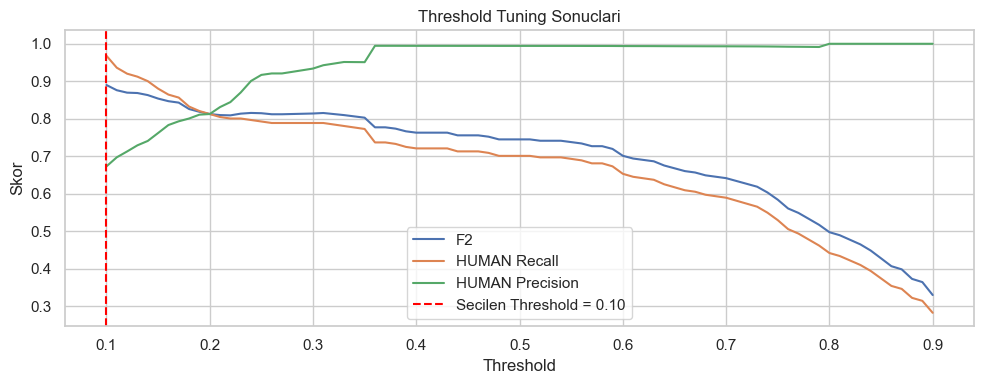

In [11]:
if best_threshold_df is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(best_threshold_df["threshold"], best_threshold_df["f2"], label="F2")
    plt.plot(best_threshold_df["threshold"], best_threshold_df["human_recall"], label="HUMAN Recall")
    plt.plot(best_threshold_df["threshold"], best_threshold_df["human_precision"], label="HUMAN Precision")
    plt.axvline(best_threshold, color="red", linestyle="--", label=f"Secilen Threshold = {best_threshold:.2f}")
    plt.xlabel("Threshold")
    plt.ylabel("Skor")
    plt.title("Threshold Tuning Sonuclari")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 12. Validation Evaluation (Threshold Ayarli)

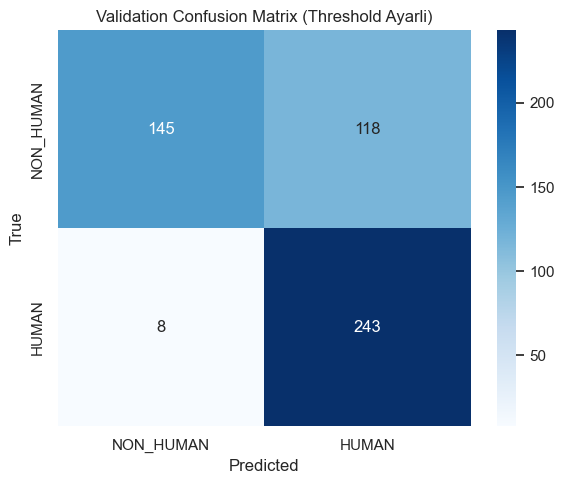

,precision,recall,f1-score,support
NON_HUMAN,0.947712,0.551331,0.697115,263.000000
HUMAN,0.673130,0.968127,0.794118,251.000000
accuracy,0.754864,0.754864,0.754864,0.754864
macro avg,0.810421,0.759729,0.745617,514.000000
weighted avg,0.813627,0.754864,0.744484,514.000000


HUMAN recall: 0.9681
HUMAN precision: 0.6731
Macro F1: 0.7456


In [12]:
def predict_dataframe_with_probs(model, dataframe: pd.DataFrame):
    loader = DataLoader(MergedAudioDataset(dataframe, training=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    model.eval()
    labels_list, probs_list = [], []
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(DEVICE, non_blocking=True)
            logits = model(features)
            probs = torch.softmax(logits, dim=1)[:, LABEL_TO_IDX["HUMAN"]]
            labels_list.extend(labels.numpy().tolist())
            probs_list.extend(probs.cpu().numpy().tolist())
    return np.array(labels_list), np.array(probs_list)


val_labels, val_human_probs = predict_dataframe_with_probs(model, val_df)
val_preds_tuned = (val_human_probs >= best_threshold).astype(int)
cm = confusion_matrix(val_labels, val_preds_tuned, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]],
    yticklabels=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix (Threshold Ayarli)")
plt.tight_layout()
plt.show()

report_dict = classification_report(
    val_labels,
    val_preds_tuned,
    labels=[0, 1],
    target_names=[IDX_TO_LABEL[0], IDX_TO_LABEL[1]],
    digits=4,
    output_dict=True,
    zero_division=0,
)
display(pd.DataFrame(report_dict).transpose())
print(f"HUMAN recall: {report_dict['HUMAN']['recall']:.4f}")
print(f"HUMAN precision: {report_dict['HUMAN']['precision']:.4f}")
print(f"Macro F1: {report_dict['macro avg']['f1-score']:.4f}")


## 13. Quick Test ve Rubble Test Benchmark

In [13]:
def load_checkpoint_for_inference(model_path: Path):
    checkpoint = torch.load(model_path, map_location=DEVICE)
    inference_model = SmallAudioCNN(num_classes=len(checkpoint["label_to_idx"])).to(DEVICE)
    inference_model.load_state_dict(checkpoint["model_state_dict"])
    inference_model.eval()
    return inference_model, checkpoint


def predict_single_wav(wav_path: str, model_path: Path = MODEL_PATH):
    inference_model, checkpoint = load_checkpoint_for_inference(model_path)
    waveform = load_audio(wav_path, target_sr=checkpoint["config"]["sample_rate"])
    waveform = crop_or_pad(waveform, target_length=int(checkpoint["config"]["sample_rate"] * checkpoint["config"]["clip_seconds"]), training=False)
    logmel = waveform_to_logmel(
        waveform,
        sr=checkpoint["config"]["sample_rate"],
        n_mels=checkpoint["config"]["n_mels"],
        n_fft=checkpoint["config"]["n_fft"],
        hop_length=checkpoint["config"]["hop_length"],
    )
    feature = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = inference_model(feature)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    human_probability = float(probs[LABEL_TO_IDX["HUMAN"]])
    predicted_label = "HUMAN" if human_probability >= checkpoint.get("decision_threshold", 0.50) else "NON_HUMAN"
    return {
        "predicted_label": predicted_label,
        "human_probability": human_probability,
        "non_human_probability": float(probs[LABEL_TO_IDX["NON_HUMAN"]]),
        "decision_threshold": float(checkpoint.get("decision_threshold", 0.50)),
    }


def run_demo_benchmark(manifest_path: Path, folder_root: Path) -> pd.DataFrame:
    manifest_df = pd.read_csv(manifest_path)
    rows = []
    for _, row in manifest_df.iterrows():
        if "variant_path" in manifest_df.columns:
            wav_path = row["variant_path"]
            file_name = Path(wav_path).name
        else:
            subfolder = "human" if row["target_label"] == "HUMAN" else "non_human"
            file_name = row["demo_name"]
            wav_path = str(folder_root / subfolder / file_name)
        pred = predict_single_wav(wav_path)
        pred["file_name"] = file_name
        pred["target_label"] = row["target_label"]
        rows.append(pred)
    results_df = pd.DataFrame(rows)
    results_df["is_correct"] = results_df["predicted_label"] == results_df["target_label"]
    return results_df


quick_results_df = run_demo_benchmark(QUICK_TEST_MANIFEST, QUICK_TEST_ROOT) if QUICK_TEST_MANIFEST.exists() else None
rubble_results_df = run_demo_benchmark(RUBBLE_TEST_MANIFEST, RUBBLE_TEST_ROOT) if RUBBLE_TEST_MANIFEST.exists() else None

if quick_results_df is not None:
    display(quick_results_df[["file_name", "target_label", "predicted_label", "human_probability", "decision_threshold", "is_correct"]])
    print(f"Quick test accuracy: {quick_results_df['is_correct'].mean():.4f}")
    print(f"Quick HUMAN recall: {quick_results_df.loc[quick_results_df['target_label'] == 'HUMAN', 'predicted_label'].eq('HUMAN').mean():.4f}")

if rubble_results_df is not None:
    display(rubble_results_df[["file_name", "target_label", "predicted_label", "human_probability", "decision_threshold", "is_correct"]])
    print(f"Rubble test accuracy: {rubble_results_df['is_correct'].mean():.4f}")
    print(f"Rubble HUMAN recall: {rubble_results_df.loc[rubble_results_df['target_label'] == 'HUMAN', 'predicted_label'].eq('HUMAN').mean():.4f}")


,file_name,target_label,predicted_label,human_probability,decision_threshold,is_correct
0,human_01_femaleSpeech.wav,HUMAN,HUMAN,0.440064,0.1,True
1,human_02_maleSpeech.wav,HUMAN,HUMAN,0.127607,0.1,True
2,human_03_femaleScream.wav,HUMAN,NON_HUMAN,0.073585,0.1,False
3,human_04_maleScream.wav,HUMAN,HUMAN,0.155812,0.1,True
4,nonhuman_01_alarm.wav,NON_HUMAN,HUMAN,0.150686,0.1,False
5,nonhuman_02_dog.wav,NON_HUMAN,HUMAN,0.231741,0.1,False
6,nonhuman_03_engine.wav,NON_HUMAN,NON_HUMAN,0.055248,0.1,True
7,nonhuman_04_fire.wav,NON_HUMAN,NON_HUMAN,0.085446,0.1,True


Quick test accuracy: 0.6250
Quick HUMAN recall: 0.7500


,file_name,target_label,predicted_label,human_probability,decision_threshold,is_correct
0,human_01_femaleSpeech_rubble.wav,HUMAN,HUMAN,0.876045,0.1,True
1,human_02_maleSpeech_rubble.wav,HUMAN,HUMAN,0.160044,0.1,True
2,human_03_femaleScream_rubble.wav,HUMAN,HUMAN,0.127872,0.1,True
3,human_04_maleScream_rubble.wav,HUMAN,HUMAN,0.262790,0.1,True
4,nonhuman_01_alarm_rubble.wav,NON_HUMAN,HUMAN,0.141465,0.1,False
5,nonhuman_02_dog_rubble.wav,NON_HUMAN,HUMAN,0.230669,0.1,False
6,nonhuman_03_engine_rubble.wav,NON_HUMAN,NON_HUMAN,0.061970,0.1,True
7,nonhuman_04_fire_rubble.wav,NON_HUMAN,NON_HUMAN,0.070626,0.1,True


Rubble test accuracy: 0.7500
Rubble HUMAN recall: 1.0000


## 14. Single WAV Inference

In [14]:
INFER_WAV_PATH = r""

if INFER_WAV_PATH:
    inference_result = predict_single_wav(INFER_WAV_PATH)
    display(pd.DataFrame([inference_result]))
else:
    print("Inference icin INFER_WAV_PATH degiskenine bir .wav dosyasi yolu verin.")


Inference icin INFER_WAV_PATH degiskenine bir .wav dosyasi yolu verin.


## 15. Report Comparison

,experiment_name,project_name,datasets_used,val_accuracy,val_macro_f1,human_recall,quick_test_accuracy,quick_test_human_recall,rubble_test_accuracy,rubble_test_human_recall
0,echo_swarm2_merged_human_vs_nonhuman,echo_swarm2,NIGENS + ESC-50 + TESS,0.896887,0.895414,0.796813,0.625,0.25,0.75,0.50
1,echo_swarm2_merged_human_vs_nonhuman_rubble_ro...,echo_swarm2,NIGENS + ESC-50 + TESS,0.754864,0.745617,0.968127,0.625,0.75,0.75,1.00
2,echo_swarm2_nigens_human_vs_nonhuman,echo_swarm2,NIGENS,0.916031,0.893739,0.967742,0.875,1.00,0.50,0.25
3,echo_swarm_scream_baseline,echo_swarm,human_screaming_detection,0.806400,0.805600,0.894700,NaN,NaN,NaN,NaN


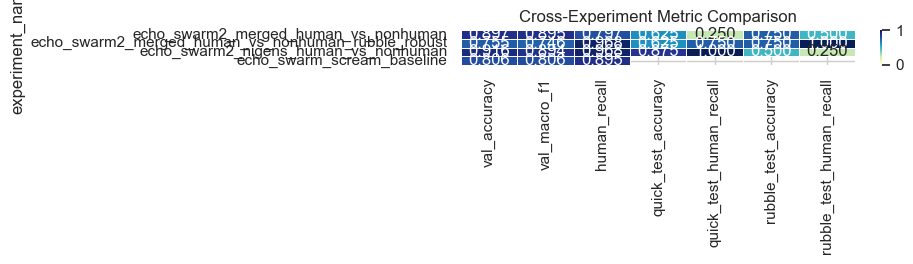

Comparison CSV updated: C:\projs\echo_swarm2\outputs\cross_project_experiment_comparison.csv


In [15]:
# EXPERIMENT_COMPARISON_SECTION
COMPARISON_CSV = Path(r"C:\projs\echo_swarm2\outputs\cross_project_experiment_comparison.csv")
COMPARISON_CSV.parent.mkdir(parents=True, exist_ok=True)
COMPARISON_PNG = COMPARISON_CSV.with_name("cross_project_experiment_comparison_heatmap.png")

def upsert_experiment_row(row: dict, csv_path: Path = COMPARISON_CSV) -> pd.DataFrame:
    new_row = pd.DataFrame([row])
    if csv_path.exists():
        current_df = pd.read_csv(csv_path)
    else:
        current_df = pd.DataFrame(columns=new_row.columns)

    for col in new_row.columns:
        if col not in current_df.columns:
            current_df[col] = pd.NA
    for col in current_df.columns:
        if col not in new_row.columns:
            new_row[col] = pd.NA

    new_row = new_row[current_df.columns]
    current_df = current_df[current_df["experiment_name"] != row["experiment_name"]]
    current_df = pd.concat([current_df, new_row], ignore_index=True)
    current_df.to_csv(csv_path, index=False)
    return current_df

def render_comparison(df: pd.DataFrame) -> None:
    ordered_cols = [
        "experiment_name",
        "project_name",
        "datasets_used",
        "val_accuracy",
        "val_macro_f1",
        "human_recall",
        "quick_test_accuracy",
        "quick_test_human_recall",
        "rubble_test_accuracy",
        "rubble_test_human_recall",
    ]
    show_cols = [col for col in ordered_cols if col in df.columns]
    display(df[show_cols].sort_values("experiment_name").reset_index(drop=True))

    metric_cols = [
        "val_accuracy",
        "val_macro_f1",
        "human_recall",
        "quick_test_accuracy",
        "quick_test_human_recall",
        "rubble_test_accuracy",
        "rubble_test_human_recall",
    ]
    metric_cols = [col for col in metric_cols if col in df.columns and df[col].notna().any()]
    if not metric_cols:
        return

    heatmap_df = df[["experiment_name"] + metric_cols].copy()
    heatmap_df[metric_cols] = heatmap_df[metric_cols].apply(pd.to_numeric, errors="coerce")
    heatmap_df = heatmap_df.set_index("experiment_name").sort_index()

    plt.figure(figsize=(max(8, len(metric_cols) * 1.4), max(2.8, len(heatmap_df) * 0.7)))
    sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".3f", linewidths=0.5)
    plt.title("Cross-Experiment Metric Comparison")
    plt.tight_layout()
    plt.savefig(COMPARISON_PNG, dpi=180, bbox_inches="tight")
    plt.show()


quick_acc = float(quick_results_df["is_correct"].mean()) if quick_results_df is not None else pd.NA
quick_hrec = float(quick_results_df.loc[quick_results_df["target_label"] == "HUMAN", "predicted_label"].eq("HUMAN").mean()) if quick_results_df is not None else pd.NA
rubble_acc = float(rubble_results_df["is_correct"].mean()) if rubble_results_df is not None else pd.NA
rubble_hrec = float(rubble_results_df.loc[rubble_results_df["target_label"] == "HUMAN", "predicted_label"].eq("HUMAN").mean()) if rubble_results_df is not None else pd.NA

summary_row = {
    "experiment_name": "echo_swarm2_merged_human_vs_nonhuman_rubble_robust",
    "project_name": "echo_swarm2",
    "notebook_path": r"C:\projs\echo_swarm2\notebooks\merged_human_vs_nonhuman_rubble_robust.ipynb",
    "datasets_used": "NIGENS + ESC-50 + TESS",
    "human_definition": "NIGENS speech/scream + ESC50 human vocal classes + TESS speech",
    "nonhuman_definition": "NIGENS selected nonhuman + curated ESC50 nonhuman classes",
    "val_accuracy": float(np.mean(val_preds_tuned == val_labels)),
    "val_macro_f1": float(report_dict["macro avg"]["f1-score"]),
    "human_recall": float(report_dict["HUMAN"]["recall"]),
    "quick_test_accuracy": quick_acc,
    "quick_test_human_recall": quick_hrec,
    "rubble_test_accuracy": rubble_acc,
    "rubble_test_human_recall": rubble_hrec,
    "decision_threshold": float(best_threshold),
}

comparison_df = upsert_experiment_row(summary_row)
render_comparison(comparison_df)
print(f"Comparison CSV updated: {COMPARISON_CSV}")
